In [53]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from unike.module.model import RotatE
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
rotate_model = RotatE(
    ent_tol=151321,
    rel_tol=31,
    dim=1024,
    margin=6.0,
    epsilon=2.0,
)
rotate_model.load_checkpoint('checkpoints/rotate/all/multi/rotate-500.pth')
rotate_model.ent_embeddings

Embedding(151321, 2048)

In [25]:
nodes = pd.read_csv('../../../kg/kg_origin/nodes.csv').get(['node_index', 'node_type'])
id2type = {row['node_index']: row['node_type'] for _, row in nodes.iterrows()}
id2type

{0: 'gene/protein',
 1: 'gene/protein',
 2: 'gene/protein',
 3: 'gene/protein',
 4: 'gene/protein',
 5: 'gene/protein',
 6: 'gene/protein',
 7: 'gene/protein',
 8: 'gene/protein',
 9: 'gene/protein',
 10: 'gene/protein',
 11: 'gene/protein',
 12: 'gene/protein',
 13: 'gene/protein',
 14: 'gene/protein',
 15: 'gene/protein',
 16: 'gene/protein',
 17: 'gene/protein',
 18: 'gene/protein',
 19: 'gene/protein',
 20: 'gene/protein',
 21: 'gene/protein',
 22: 'gene/protein',
 23: 'gene/protein',
 24: 'gene/protein',
 25: 'gene/protein',
 26: 'gene/protein',
 27: 'gene/protein',
 28: 'gene/protein',
 29: 'gene/protein',
 30: 'gene/protein',
 31: 'gene/protein',
 32: 'gene/protein',
 33: 'gene/protein',
 34: 'gene/protein',
 35: 'gene/protein',
 36: 'gene/protein',
 37: 'gene/protein',
 38: 'gene/protein',
 39: 'gene/protein',
 40: 'gene/protein',
 41: 'gene/protein',
 42: 'gene/protein',
 43: 'gene/protein',
 44: 'gene/protein',
 45: 'gene/protein',
 46: 'gene/protein',
 47: 'gene/protein',
 4

In [16]:
embeddings = rotate_model.ent_embeddings.weight.data.cpu().numpy()
embeddings.shape

(151321, 2048)

In [18]:
embeddings_pca = PCA(n_components=50).fit_transform(embeddings)
embeddings_2d = TSNE(n_components=2).fit_transform(embeddings_pca).T
embeddings_2d.shape

(2, 151321)

In [22]:
embeddings_2d

array([[-62.233215 , -76.41821  , -92.93783  , ...,  47.170044 ,
         65.51099  ,  36.215042 ],
       [  3.0141802,  39.35686  ,  50.82644  , ...,  42.4944   ,
        -66.69137  ,  32.836643 ]], dtype=float32)

In [34]:
types = list(id2type.values())

In [45]:

color_map = {
    'gene/protein': 'blue',
    'anatomy': 'cyan',
    'biological_process': 'magenta',
    'cellular_component': 'yellow',
    'disease': 'red',
    'drug': 'purple',
    'effect/phenotype': 'plum',
    'exposure': 'orange',
    'molecular_function': 'lightgreen',
    'pathway': 'sienna',
}
colors = [ color_map[t] for t in types]

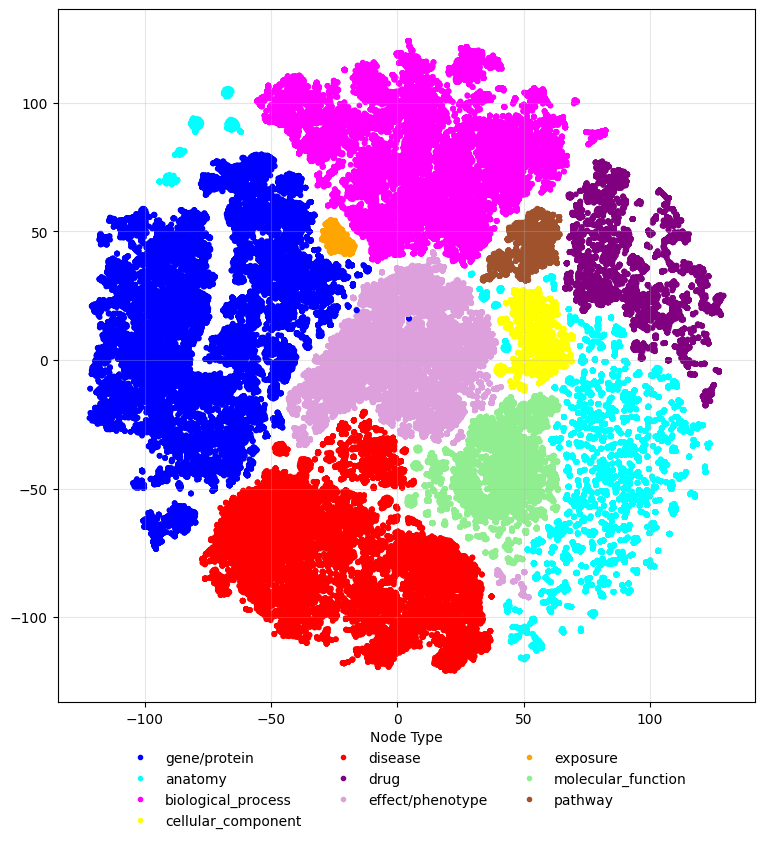

In [58]:
plt.figure(figsize=(9, 9))
scatter = plt.scatter(embeddings_2d[0, :], embeddings_2d[1, :], label=types, color=colors, s=10)
plt.grid(True, alpha=0.3)

legend_handles = [mlines.Line2D([], [], color=color_map[t], marker='o', linestyle='None', markersize=3, label=t) for t in color_map]
plt.legend(handles=legend_handles, title='Node Type', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)

plt.show()